# Ex14b RNN stock return predictions

In [1]:
import pandas as pd
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/lazyprogrammer/machine_learning_examples/master/tf2.0/sbux.csv')
df.head()

,date,open,high,low,close,volume,Name
0,2013-02-08,27.920,28.325,27.920,28.185,7146296,SBUX
1,2013-02-11,28.260,28.260,27.930,28.070,5457354,SBUX
2,2013-02-12,28.000,28.275,27.975,28.130,8665592,SBUX
3,2013-02-13,28.230,28.230,27.750,27.915,7022056,SBUX
4,2013-02-14,27.765,27.905,27.675,27.775,8899188,SBUX


In [3]:
df['prevClose'] = df['close'].shift(1)


In [4]:
df.head()

,date,open,high,low,close,volume,Name,prevClose
0,2013-02-08,27.920,28.325,27.920,28.185,7146296,SBUX,NaN
1,2013-02-11,28.260,28.260,27.930,28.070,5457354,SBUX,28.185
2,2013-02-12,28.000,28.275,27.975,28.130,8665592,SBUX,28.070
3,2013-02-13,28.230,28.230,27.750,27.915,7022056,SBUX,28.130
4,2013-02-14,27.765,27.905,27.675,27.775,8899188,SBUX,27.915


In [ ]:
D = 1
T = 20
K = 1
M = 5
L = 2
bi = False
dropout = 0
lr = 0.01

### we're interested in stock return which defined by this formula $R :=\frac{V_{close}-V_{prev_close}}{V_{prev_close}}$

In [6]:
df['return'] = (df['close']-df['prevClose'])/df['prevClose']

In [7]:
df.head()

,date,open,high,low,close,volume,Name,prevClose,return
0,2013-02-08,27.920,28.325,27.920,28.185,7146296,SBUX,NaN,NaN
1,2013-02-11,28.260,28.260,27.930,28.070,5457354,SBUX,28.185,-0.004080
2,2013-02-12,28.000,28.275,27.975,28.130,8665592,SBUX,28.070,0.002138
3,2013-02-13,28.230,28.230,27.750,27.915,7022056,SBUX,28.130,-0.007643
4,2013-02-14,27.765,27.905,27.675,27.775,8899188,SBUX,27.915,-0.005015


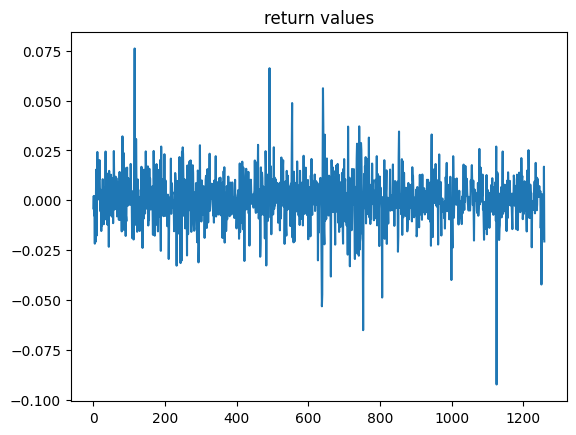

In [8]:
plt.plot(df['return'])
plt.title('return values')
plt.show()

let's see how are return scatter along the histogram

<Axes: >

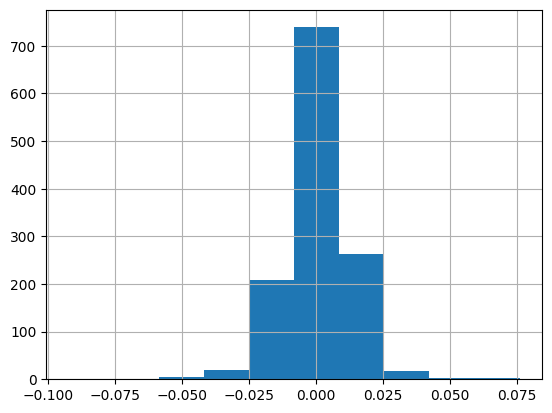

In [9]:
df['return'].hist()

values are extremely small and centered around 0.00

In [10]:
series = df['return'].values[1:].reshape(-1,1)

In [11]:
scaler=StandardScaler()
N = len(series)

scaler.fit(series[:N//2])
series = scaler.transform(series).flatten()

In [12]:
X,y =[],[]
for t in range(N- T):
    X.append(series[t:t+T])
    y.append(series[t+T])

In [13]:
N = len(X)
print(N)


1238


In [14]:
X = np.array(X).reshape(-1,T,D).astype(np.float32)
y = np.array(y).reshape(-1,1).astype(np.float32)

X_train,X_test =np.array(X[:N//2]),np.array(X[N//2:])
y_train,y_test = y[:N//2],y[N//2:]


In [15]:
device = print('cuda:0' if torch.cuda.is_available() else 'cpu')

cuda:0


In [16]:
X_train = torch.from_numpy(X_train).to(device)
X_test = torch.from_numpy(X_test).to(device)
y_train = torch.from_numpy(y_train).to(device)
y_test = torch.from_numpy(y_test).to(device)

In [17]:
class LSTMModel(nn.Module):
    def __init__(self, input_size,hidden_size,output_size,num_layers,bi=True,dropout=0.2):
        super().__init__()
        self.D =input_size
        self.L = num_layers
        self.M = hidden_size
        self.K = output_size

        self.biFactor = 2 if bi else 1

        self.rnn = nn.LSTM(input_size=self.D,
                           hidden_size=self.M,
                           num_layers=self.L,
                           batch_first=True,
                           bidirectional=bi,dropout=dropout)
        self.fc = nn.Linear(self.M * self.biFactor, self.K)

    def forward(self,X):
        h0 = torch.zeros(self.biFactor*self.L,X.size(0),self.M).to(device)
        c0 = torch.zeros(self.biFactor*self.L,X.size(0),self.M).to(device)

        out,(hn,cn) = self.rnn(X,(h0,c0))
        out = self.fc(out[:,-1,:])
        return out


In [18]:
epochs = 200

In [19]:
lstm = LSTMModel(D,M,K,L,bi=bi,dropout=dropout).to(device)
optimizer = torch.optim.Adam(lstm.parameters(),lr=lr)
criterion = nn.MSELoss().to(device)
# scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer,max_lr=1e-3,steps_per_epoch=len(X_train), epochs=epochs)

In [20]:
def single_epoch(model,optimizer: torch.optim.Optimizer,criterion: nn.Module,X,y,is_training=True):
    optimizer.zero_grad()

    input = X.view(-1,T,D).to(device)
    y_hat = model(input)
    loss = criterion(y_hat,y)

    if is_training:
        loss.backward()
        optimizer.step()
        # scheduler.step(loss)
    
    return y_hat,loss.item()

    

In [21]:
train_losses = []
test_losses = []

for epoch in range(epochs):
    optimizer.zero_grad()
    _,train_loss = single_epoch(lstm,optimizer,criterion,X_train,y_train,True)
    _,test_loss = single_epoch(lstm,optimizer,criterion,X_test,y_test,False)
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    print(f'{epoch}/{epochs} train loss {train_losses[-1]} test loss {test_losses[-1]}')

0/200 train loss 1.121335506439209 test loss 1.0967137813568115
1/200 train loss 1.1067068576812744 test loss 1.0882903337478638
2/200 train loss 1.0942010879516602 test loss 1.0817005634307861
3/200 train loss 1.083654761314392 test loss 1.0768060684204102
4/200 train loss 1.074918508529663 test loss 1.0735043287277222
5/200 train loss 1.0678985118865967 test loss 1.0717196464538574
6/200 train loss 1.062552809715271 test loss 1.0713601112365723
7/200 train loss 1.058840036392212 test loss 1.0722646713256836
8/200 train loss 1.056656837463379 test loss 1.074159026145935
9/200 train loss 1.0557867288589478 test loss 1.076635718345642
10/200 train loss 1.055880069732666 test loss 1.0792049169540405
11/200 train loss 1.0564976930618286 test loss 1.0814151763916016
12/200 train loss 1.0572165250778198 test loss 1.0829648971557617
13/200 train loss 1.0577309131622314 test loss 1.0837376117706299
14/200 train loss 1.057891607284546 test loss 1.0837661027908325
15/200 train loss 1.0576821565

In [22]:

print(f'lstm(D={D},M={M},K={K},L={L},bidirectional = {bi} dropout={dropout}) lr={lr}')

lstm(D=1,M=5,K=1,L=1,bidirectional = False dropout=0) lr=0.01


<b>scheduler was ReduceOnPlatue(optimizer,'min',patience=10) criterion = nn.MSE()</b>

lstm(D=1,M=5,K=1,L=1,bidirectional = False) 799/800 train loss 0.6069036722183228 test loss 2.007629156112671


lstm(D=1,M=5,K=1,L=5,bidirectional = False) 799/800 train loss 1.0541598796844482 test loss 1.0733938217163086

lstm(D=1,M=32,K=1,L=5,bidirectional = False) 799/800 train loss 0.010844520293176174 test loss 3.120149612426758

lstm(D=1,M=32,K=1,L=16,bidirectional = False) 799/800 train loss 1.0540679693222046 test loss 1.0718467235565186

lstm(D=1,M=16,K=1,L=5,bidirectional = False dropout=0.2) lr=0.001 799/800 train loss 1.054933786392212 test loss 1.0708281993865967

<b>scheduler was OneCycleLR(optimizer,max_lr=1e-3,steps_per_epoch=len(X_train), epochs=epochs) criterion = nn.SmoothL1Loss(beta=1.0)</b>
lstm(D=1,M=16,K=1,L=5,bidirectional = False dropout=0.25) lr=0.0005 799/800 train loss 0.4005145728588104 test loss 0.38926345109939575 


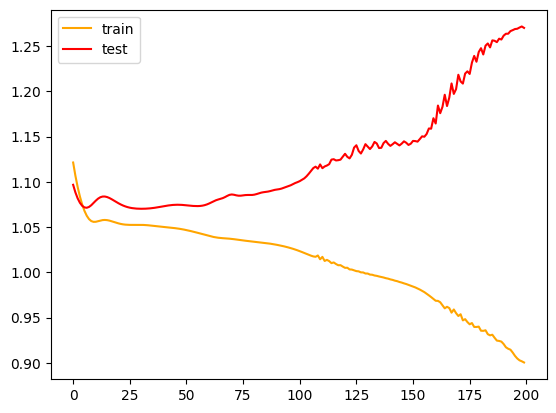

In [23]:
plt.plot(train_losses,color='orange',label='train')
plt.plot(test_losses,color='red',label='test')
plt.legend()
plt.show()

In [24]:
y_hats = []
X_last =X_test[0]

for i in range(y_test.shape[0]):
    y_hat,_ = single_epoch(lstm,optimizer,criterion,X_last,y_test[i],False)
    y_hats.append(y_hat.item())
    print('pre',X_last)
    X_last = torch.cat((X_last[1:],y_hat))
    print('post',X_last)

pre tensor([[ 0.1366],
        [ 0.4425],
        [ 0.7002],
        [-0.2845],
        [ 0.2767],
        [ 0.6335],
        [ 0.3429],
        [-2.6143],
        [-0.1414],
        [-1.4542],
        [ 0.0209],
        [-0.0533],
        [ 0.5978],
        [ 0.2692],
        [ 0.8374],
        [ 0.0323],
        [-0.4439],
        [-2.6763],
        [-4.5375],
        [-4.0449]])
post tensor([[ 0.4425],
        [ 0.7002],
        [-0.2845],
        [ 0.2767],
        [ 0.6335],
        [ 0.3429],
        [-2.6143],
        [-0.1414],
        [-1.4542],
        [ 0.0209],
        [-0.0533],
        [ 0.5978],
        [ 0.2692],
        [ 0.8374],
        [ 0.0323],
        [-0.4439],
        [-2.6763],
        [-4.5375],
        [-4.0449],
        [-1.2694]], grad_fn=<CatBackward0>)
pre tensor([[ 0.4425],
        [ 0.7002],
        [-0.2845],
        [ 0.2767],
        [ 0.6335],
        [ 0.3429],
        [-2.6143],
        [-0.1414],
        [-1.4542],
        [ 0.0209],
        [-0

c:\Users\liora\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\nn\modules\loss.py:610: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([1, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


tensor([[-0.3807],
        [-0.3807],
        [-0.3807],
        [-0.3807],
        [-0.3807],
        [-0.3807],
        [-0.3807],
        [-0.3807],
        [-0.3807],
        [-0.3807],
        [-0.3807],
        [-0.3807],
        [-0.3807],
        [-0.3807],
        [-0.3807],
        [-0.3807],
        [-0.3807],
        [-0.3807],
        [-0.3807],
        [-0.3807]], grad_fn=<CatBackward0>)
post tensor([[-0.3807],
        [-0.3807],
        [-0.3807],
        [-0.3807],
        [-0.3807],
        [-0.3807],
        [-0.3807],
        [-0.3807],
        [-0.3807],
        [-0.3807],
        [-0.3807],
        [-0.3807],
        [-0.3807],
        [-0.3807],
        [-0.3807],
        [-0.3807],
        [-0.3807],
        [-0.3807],
        [-0.3807],
        [-0.3807]], grad_fn=<CatBackward0>)
pre tensor([[-0.3807],
        [-0.3807],
        [-0.3807],
        [-0.3807],
        [-0.3807],
        [-0.3807],
        [-0.3807],
        [-0.3807],
        [-0.3807],
        [-

In [25]:
ys = y_test.detach().cpu().numpy()

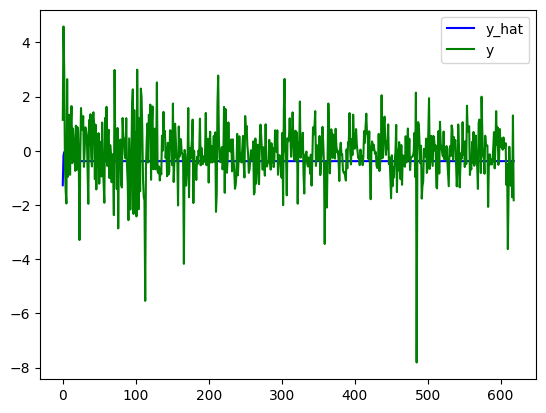

In [26]:
plt.plot(y_hats,color='blue',label='y_hat')
plt.plot(ys,color='green',label='y')
plt.legend()
plt.show()

In [27]:
inps = X_test.view(-1,T,D).to(device)
y_hats = lstm(inps)
y_hats = y_hats.detach().cpu().numpy()

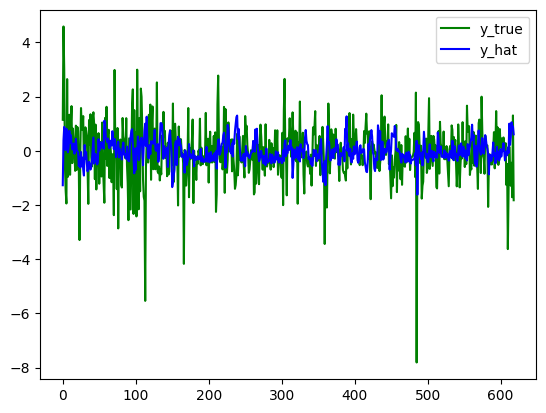

In [28]:
plt.plot(y_test,label='y_true',color='green')
plt.plot(y_hats,label='y_hat',color='blue')

plt.legend()
plt.show()